# Trust-Drift Fusion (TDF) — Full Evaluation Suite (TON_IoT)
Real TON_IoT network traffic data (via Kaggle). Covers: baseline comparison (5 models, 8 metrics),
ablation study, context-aware (per-regime) fusion, cost-sensitive thresholds, SHAP
explainability, drift-adaptive retraining, and adversarial robustness testing.

In [1]:
# Runtime dependencies used by the notebook.
# Install only when a package is unavailable; this keeps the publication notebook
# readable and avoids unnecessary reinstalls on Colab / Jupyter runtimes.
import importlib.util
import subprocess
import sys

# Import-module name -> pip distribution name.  `sklearn` is the import name;
# the corresponding PyPI package is `scikit-learn`.
_REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "shap": "shap",
    "kagglehub": "kagglehub",
}
_MISSING = [pkg for module, pkg in _REQUIRED.items()
            if importlib.util.find_spec(module) is None]

if _MISSING:
    print("Installing missing packages:", ", ".join(_MISSING))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_MISSING])
else:
    print("All required Python packages are already available.")


All required Python packages are already available.


## 1. Load real dataset (TON_IoT)
Requires a free Kaggle account + API token. `kagglehub.login()` below will print a link -- click it, authorize, and paste the token back when prompted.

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os

# --- Robust Kaggle authentication / download ---
# Prefer existing credentials. Only start an interactive login flow when an
# authenticated download is not possible. This avoids an unnecessary login
# prompt during normal Run-All execution.
DATASET_ID = "arnobbhowmik/ton-iot-network-dataset"

try:
    path = kagglehub.dataset_download(DATASET_ID)
except Exception as first_download_error:
    print("Kaggle dataset download failed with existing credentials.")
    print("Attempting interactive Kaggle authentication...")
    kagglehub.login()
    try:
        path = kagglehub.dataset_download(DATASET_ID)
    except Exception as second_download_error:
        raise RuntimeError(
            "Unable to download TON_IoT after Kaggle authentication. "
            "Verify Kaggle credentials, internet access, and dataset ID."
        ) from second_download_error

print("Downloaded to:", path)

csv_files = sorted(
    f for f in os.listdir(path)
    if f.lower().endswith(".csv")
)
print("CSV files found:", csv_files)

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files were found in the downloaded directory: {path}"
    )

# Prefer the canonical network-flow CSV. If the mirror uses another filename,
# validate candidates by requiring the expected label column before selecting.
preferred = [f for f in csv_files if "train_test_network" in f.lower()]
candidate_files = preferred + [f for f in csv_files if f not in preferred]

csv_path = None
for fname in candidate_files:
    candidate_path = os.path.join(path, fname)
    try:
        sample = pd.read_csv(candidate_path, nrows=10, low_memory=False)
    except Exception:
        continue
    # Prefer the real TON_IoT network table: it must have the binary label
    # plus at least one feature column. We do not infer row counts from this
    # 10-row schema probe; the selected CSV is loaded exactly once below.
    if "label" in sample.columns and len(sample.columns) > 1:
        csv_path = candidate_path
        break

if csv_path is None:
    raise ValueError(
        "No downloaded CSV contains the required 'label' column. "
        f"Candidates: {csv_files}"
    )

print("Using:", csv_path)

# Load the selected experiment CSV ONCE, in full. No nrows, sampling, chunk
# truncation, or row slicing is used here.
df = pd.read_csv(csv_path, low_memory=False)
RAW_ROW_COUNT = len(df)
RAW_COLUMNS = tuple(df.columns)

if "label" not in df.columns:
    raise ValueError("Expected binary 'label' column was not found.")
if RAW_ROW_COUNT == 0:
    raise ValueError("Selected TON_IoT CSV contains zero rows.")

print(f"Loaded ENTIRE CSV once: {RAW_ROW_COUNT:,} rows, {df.shape[1]} columns")
print(df["label"].value_counts(dropna=False))
df.head()


Downloaded to: /Users/likithgagan/.cache/kagglehub/datasets/arnobbhowmik/ton-iot-network-dataset/versions/1
CSV files found: ['train_test_network.csv']
Using: /Users/likithgagan/.cache/kagglehub/datasets/arnobbhowmik/ton-iot-network-dataset/versions/1/train_test_network.csv
Loaded ENTIRE CSV once: 211,043 rows, 44 columns
label
1    161043
0     50000
Name: count, dtype: int64


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [3]:
# --- Preprocess TON_IoT into the same schema evaluate.py / models.py expect:
#     numeric feature columns + a 'label' column of 'Normal'/'Attack' ---

# Drop high-cardinality / leaky identifier columns and the fine-grained
# attack-type column (keep only the binary label, matching the paper's
# Normal-vs-Attack framing).
drop_cols = [c for c in ["src_ip", "dst_ip", "ts", "type"] if c in df.columns]
data = df.drop(columns=drop_cols)

# Binary label: TON_IoT already ships 'label' as 0/1 (0=Normal, 1=Attack)
data["label"] = data["label"].map({0: "Normal", 1: "Attack"})

# Standardize missing values in the remaining categorical (object-dtype)
# columns (proto, service, conn_state, ssl/http/dns fields, etc.) to an
# explicit "missing" token. This is schema cleanup only -- no encoding
# vocabulary or fitted statistic is created here.
#
# Correction (preprocessing-vocabulary leakage fix): one-hot encoding of
# these categorical columns previously happened HERE, on the full 20,000-row
# dataframe before any train/test split existed. That derives the one-hot
# *vocabulary* (which dummy columns exist at all, and which category
# values they represent) from data that includes what later becomes the test
# set, which is exactly the kind of test-set-derived preprocessing statistic
# the paper's leakage-free protocol is meant to rule out. One-hot encoding is
# now deferred to the baseline-comparison cell (Section 3), where it is fit
# on the training split ONLY and then applied to the test split with that
# training vocabulary frozen (test-only categories are dropped rather than
# learned; categories absent from a given test row are zero-filled).
# Categorical columns are kept as object-dtype strings past this point.
cat_cols = [c for c in data.columns
            if not pd.api.types.is_numeric_dtype(data[c]) and c != "label"]
data[cat_cols] = data[cat_cols].fillna("missing")

# Fill any remaining numeric NaNs (TON_IoT has some missing DNS/HTTP/SSL
# fields) with a fixed constant (0, meaning "field not applicable/absent").
# This is a domain-motivated constant, not a statistic estimated from the
# data (e.g. a train-set mean/median), so applying it before the split does
# not leak any train/test distributional information.
num_cols = [c for c in data.columns if c not in cat_cols and c != "label"]
data[num_cols] = data[num_cols].fillna(0)

# --- Use the complete loaded dataset ---
# This notebook intentionally uses every available row after schema cleanup.
# to the train/test split below, so the models train on the full dataset.
#
# This preserves the leakage-safe protocol: raw rows are kept intact here,
# then Section 3 splits the COMPLETE dataset into train/test before fitting
# the one-hot vocabulary on the training split only.

print(f"Using all available rows: {len(data):,}")
assert len(data) == RAW_ROW_COUNT, (
    f"Row-count changed during schema preprocessing: raw={RAW_ROW_COUNT}, "
    f"preprocessed={len(data)}"
)
assert len(data.index.unique()) == RAW_ROW_COUNT, "Duplicate row index detected before splitting."
assert data["label"].notna().all(), "Missing labels detected after preprocessing."
assert set(data["label"].unique()).issubset({"Normal", "Attack"}), \
    f"Unexpected labels: {sorted(data['label'].dropna().unique().tolist())}"

# Keep the complete pre-encoding dataframe in memory. One-hot encoding happens
# later, split-safe, in Section 3. Avoid writing and re-reading another copy of
# the dataset so the experiment has one authoritative in-memory source.
df = data
print(f"Full dataset preserved in memory: {len(df):,} rows x {df.shape[1]-1} feature columns")
df.head()


Using all available rows: 211,043
Full dataset preserved in memory: 211,043 rows x 40 feature columns


,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,4444,49178,tcp,-,290.371539,101568,2592,OTH,0,108,...,0,0,0,-,-,-,-,-,-,Attack
1,49180,8080,tcp,-,0.000102,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,Attack
2,49180,8080,tcp,-,0.000148,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,Attack
3,49180,8080,tcp,-,0.000113,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,Attack
4,49180,8080,tcp,-,0.000130,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,Attack


## 2. Models: 4 baselines + Trust-Drift Fusion (TDF)

In [4]:
"""
Defines the 4 baseline models and the proposed Trust-Drift Fusion (TDF)
model used in Section IV of the paper. Each model exposes:
    fit(X_train, y_train)
    score(X_test) -> continuous risk score in [0, 1] (higher = more attack-like)
so that a common threshold-sweep / metric routine can evaluate all of them.
"""
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score


class StaticThresholdModel:
    """Flags a window as Attack if any single feature exceeds
    mean + k*std learned from the training (mostly-normal) partition."""

    def __init__(self, k=3.0):
        self.k = k

    def fit(self, X, y):
        normal = X[y == 0]
        self.mu = normal.mean(axis=0)
        self.sigma = normal.std(axis=0) + 1e-9
        return self

    def score(self, X):
        z = np.abs((X - self.mu) / self.sigma)
        max_z = z.max(axis=1)
        return np.clip(max_z / (self.k * 2), 0, 1)


class NaiveBayesModel:
    def fit(self, X, y):
        self.scaler = StandardScaler().fit(X)
        self.clf = GaussianNB().fit(self.scaler.transform(X), y)
        return self

    def score(self, X):
        return self.clf.predict_proba(self.scaler.transform(X))[:, 1]


class IsolationForestModel:
    """Standalone unsupervised Isolation Forest (no drift/policy fusion)."""

    def __init__(self, n_estimators=100, contamination=0.19, random_state=42):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.random_state = random_state

    def fit(self, X, y):
        self.scaler = StandardScaler().fit(X)
        self.model = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state,
        ).fit(self.scaler.transform(X))
        raw = -self.model.score_samples(self.scaler.transform(X))
        self.rmin, self.rmax = raw.min(), raw.max()
        return self

    def score(self, X):
        raw = -self.model.score_samples(self.scaler.transform(X))
        return np.clip((raw - self.rmin) / (self.rmax - self.rmin + 1e-9), 0, 1)


class LogisticRegressionModel:
    def fit(self, X, y):
        self.scaler = StandardScaler().fit(X)
        self.clf = LogisticRegression(max_iter=1000).fit(
            self.scaler.transform(X), y
        )
        return self

    def score(self, X):
        return self.clf.predict_proba(self.scaler.transform(X))[:, 1]


class TrustDriftFusionModel:
    """Proposed model: fuses an Isolation Forest anomaly score (AS), an
    training-reference resource-drift score (RDS, Z-score based), and a Random-Forest
    attack probability (RF) into a single Hybrid Threat score via weighted
    fusion (Eq. 4 in the paper). Fusion weights are auto-tuned by grid
    search on a held-out validation split of the training data, rather
    than fixed by hand."""

    def __init__(self, n_estimators=200, contamination=0.19, random_state=42,
                 val_size=0.25, weight_step=0.05, min_weight=0.0,
                 threshold_mode="f1", cost_fn=5.0, cost_fp=1.0):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.random_state = random_state
        self.val_size = val_size
        self.weight_step = weight_step
        self.min_weight = min_weight
        # threshold_mode: "f1" (default, maximizes F1) or "cost" (minimizes
        # cost_fn*FN + cost_fp*FP -- e.g. a missed attack costing 5x more
        # than a false quarantine action, reflecting real operational risk
        # rather than treating both error types as equally bad).
        self.threshold_mode = threshold_mode
        self.cost_fn = cost_fn
        self.cost_fp = cost_fp

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        from sklearn.ensemble import RandomForestClassifier

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        if X.ndim != 2 or len(X) != len(y):
            raise ValueError("X must be 2D and have the same number of rows as y.")
        if len(X) < 10:
            raise ValueError("Not enough rows for a stable train/validation split.")
        if np.unique(y).size < 2:
            raise ValueError("TDF requires both Normal and Attack labels in the training data.")
        if not np.isfinite(X).all():
            raise ValueError("Non-finite feature values detected before TDF fitting.")

        # Hold out a validation split from the training data only (test set
        # is never touched here) to tune the fusion weights.
        X_sub, X_val, y_sub, y_val = train_test_split(
            X, y, test_size=self.val_size, random_state=self.random_state,
            stratify=y if y.sum() > 1 else None,
        )
        assert len(X_sub) + len(X_val) == len(X)
        assert np.unique(y_sub).size == 2 and np.unique(y_val).size == 2, \
            "Training and validation partitions must both contain both classes."

        self.scaler = StandardScaler().fit(X_sub)
        Xs_sub = self.scaler.transform(X_sub)

        # Anomaly signal (unsupervised)
        self.iso = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state,
        ).fit(Xs_sub)
        raw = -self.iso.score_samples(Xs_sub)
        self.as_min, self.as_max = raw.min(), raw.max()

        # Resource-drift reference (Normal windows only; fixed after training)
        normal = X_sub[y_sub == 0]
        self.mu = normal.mean(axis=0)
        self.sigma = normal.std(axis=0) + 1e-9

        # Supervised signal: real Random Forest (matches Eq. 3 in the paper)
        self.rf = RandomForestClassifier(
            n_estimators=self.n_estimators, random_state=self.random_state,
            class_weight="balanced",
        ).fit(Xs_sub, y_sub)

        # --- Grid-search fusion weights on the validation split ---
        AS_v, RDS_v, RF_v = self._components(X_val)
        best_score, best_w, best_t = -1e18, (0.35, 0.25, 0.40), 0.5
        step = self.weight_step
        grid = np.arange(0, 1 + 1e-9, step)
        mw = self.min_weight
        for w_as in grid:
            for w_rds in grid:
                w_rf = 1 - w_as - w_rds
                if w_rf < 0 or w_rf > 1:
                    continue
                if mw > 0 and (w_as < mw or w_rds < mw or w_rf < mw):
                    continue  # enforce every signal keeps a meaningful floor
                HT = w_as * AS_v + w_rds * RDS_v + w_rf * RF_v
                t, score = self._select_threshold(y_val, HT)
                if score > best_score:
                    best_score, best_w, best_t = score, (w_as, w_rds, w_rf), t
        self.w_as, self.w_rds, self.w_rf = best_w
        self.threshold = best_t

        # Expose the validation split (and its component scores) so other
        # tools (ablation study, cost-threshold analysis, etc.) can reuse
        # the exact same leakage-free split rather than re-deriving it.
        self.X_val_, self.y_val_ = X_val, y_val
        self.AS_val_, self.RDS_val_, self.RF_val_ = AS_v, RDS_v, RF_v
        return self

    def _select_threshold(self, y_true, scores):
        """Returns (threshold, objective_value) using whichever selection
        mode this model was configured with."""
        if self.threshold_mode == "cost":
            return best_cost_threshold(y_true, scores, self.cost_fn, self.cost_fp)
        t = best_f1_threshold_local(y_true, scores)
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        return t, f1

    def _components(self, X):
        Xs = self.scaler.transform(X)
        raw = -self.iso.score_samples(Xs)
        AS = np.clip((raw - self.as_min) / (self.as_max - self.as_min + 1e-9), 0, 1)

        z = np.abs((X - self.mu) / self.sigma)
        RDS = np.clip(z.mean(axis=1) / 4.0, 0, 1)

        RF = self.rf.predict_proba(Xs)[:, 1]
        return AS, RDS, RF

    def score(self, X):
        AS, RDS, RF = self._components(X)
        HT = self.w_as * AS + self.w_rds * RDS + self.w_rf * RF
        return np.clip(HT, 0, 1)


def _threshold_grid_stats(y_true, scores, thresholds=None):
    """Compute TP/FP/FN for the notebook's fixed threshold grid in O(n + k) time.

    This is exactly equivalent to evaluating every threshold in ascending
    order, but avoids creating a full (rows × thresholds) prediction matrix.
    """
    y_true = np.asarray(y_true, dtype=np.int8)
    scores = np.asarray(scores, dtype=float)
    thresholds = (np.linspace(0.01, 0.99, 99)
                  if thresholds is None else np.asarray(thresholds, dtype=float))
    # k[i] = number of grid thresholds <= scores[i].
    k = np.searchsorted(thresholds, scores, side="right")
    hist_all = np.bincount(k, minlength=len(thresholds) + 1)
    hist_pos = np.bincount(k, weights=y_true, minlength=len(thresholds) + 1)
    # For threshold j, predicted-positive rows are buckets j+1 ... end.
    pred_pos = np.cumsum(hist_all[::-1])[::-1][1:]
    tp = np.cumsum(hist_pos[::-1])[::-1][1:]
    total_pos = float(y_true.sum())
    fp = pred_pos - tp
    fn = total_pos - tp
    return thresholds, tp, fp, fn


def best_f1_threshold_local(y_true, scores):
    """Return the same 0.01..0.99 fixed-grid F1-optimal threshold as before,
    but compute all 99 candidates without 99 full prediction passes."""
    thresholds, tp, fp, fn = _threshold_grid_stats(y_true, scores)
    denom = 2.0 * tp + fp + fn
    f1 = np.divide(2.0 * tp, denom, out=np.zeros_like(tp, dtype=float), where=denom > 0)
    # np.argmax returns the first maximum, matching the original ascending loop.
    return float(thresholds[int(np.argmax(f1))])


def best_cost_threshold(y_true, scores, cost_fn=5.0, cost_fp=1.0):
    """Return the same fixed-grid threshold minimizing cost_fn*FN + cost_fp*FP,
    using a vectorized confusion-count calculation. A negative minimum cost is
    returned so callers can continue to maximize the objective exactly as before."""
    thresholds, _tp, fp, fn = _threshold_grid_stats(y_true, scores)
    costs = cost_fn * fn + cost_fp * fp
    # First minimum preserves the original ascending-threshold tie behavior.
    return float(thresholds[int(np.argmin(costs))]), -float(np.min(costs))


def severity_bands_from_cost(model, cost_schedule=(1.0, 3.0, 8.0)):
    """Derives the 3 severity-band cutoffs (Trusted/Monitored, Monitored/
    Elevated, Elevated/Critical) from an escalating cost schedule instead
    of the fixed 80/60/35 constants, using the model's own stored
    validation split. cost_schedule gives the false-negative:false-positive
    cost ratio required to justify each successive escalation tier (e.g.
    1.0 = "Monitor vs Log&Watch" boundary treats both errors equally;
    8.0 = "Isolate vs Quarantine&Escalate" boundary requires a missed
    attack to be judged 8x worse than an unnecessary quarantine before the
    system will escalate that far). Returns 3 Trust-Score cutoffs (0-100),
    highest first, matching the T>=tau1 / tau2<=T<tau1 / tau3<=T<tau2 /
    T<tau3 structure in Eq. 6 of the paper.
    """
    AS_v, RDS_v, RF_v = model.AS_val_, model.RDS_val_, model.RF_val_
    HT_v = model.w_as * AS_v + model.w_rds * RDS_v + model.w_rf * RF_v
    cutoffs = []
    for ratio in cost_schedule:
        t_ht, _ = best_cost_threshold(model.y_val_, HT_v, cost_fn=ratio, cost_fp=1.0)
        trust_cutoff = 100 - 100 * t_ht  # HT -> Trust Score, same mapping as Eq. 5
        cutoffs.append(trust_cutoff)
    return sorted(cutoffs, reverse=True)


MODEL_REGISTRY = {
    "Static Threshold": StaticThresholdModel,
    "Naive Bayes": NaiveBayesModel,
    "Isolation Forest": IsolationForestModel,
    "Logistic Regression": LogisticRegressionModel,
    "TDF (Proposed)": TrustDriftFusionModel,
}

**Note on the standalone Isolation Forest baseline.** `IsolationForestModel` and the anomaly-score (AS) branch inside `TrustDriftFusionModel` both fit `IsolationForest` on `Xs_sub` -- the sub-train partition containing *both* classes (roughly 76% Attack / 24% Normal in this dataset), not on Normal-only rows. Because Isolation Forest is unsupervised, it implicitly treats whichever population is easiest to isolate as the "anomaly," and with an Attack-majority training population that ends up being the minority Normal windows -- the opposite of the Attack-vs-Normal target label. This is the reason the standalone Isolation Forest baseline later scores *below* random guessing (ROC-AUC well under 0.50; see Table II / Section V-C). It is not a bug in the fusion pipeline: the resource-drift channel (RDS) is fit on Normal-only rows exactly as intended, and TDF's grid search correctly assigns AS a small weight (0.10) precisely because of this weak, sometimes inverted signal. Worth stating explicitly in the paper so a reader isn't left assuming the sub-random AUC is a measurement error.

## 3. Baseline comparison (Table II + figures)

**Correction (test-set leakage fix, verified):** the baseline-comparison cell below previously selected every model's decision threshold with `best_f1_threshold_local(y_test, scores)`, including for TDF, which overrode TDF's own internal validation-based threshold. This has been corrected: every baseline now gets its own train/validation split (mirroring `TrustDriftFusionModel`'s existing `val_size=0.25, random_state=42` convention), is fit on the sub-train partition only, and has its threshold selected and frozen on the held-out validation partition. TDF is unchanged -- it already did this internally -- and now simply reuses its own frozen `model.threshold` instead of having it overwritten. `y_test` is used only in the final metrics block.

This fix has since been verified with a full fresh-kernel Run-All against the real, Kaggle-downloaded TON_IoT CSV. The outputs shown below (and throughout the notebook) are from that completed run, not stale/cleared placeholders.

**Correction (preprocessing-vocabulary leakage fix, verified):** Section 1 previously one-hot-encoded all categorical columns (`pd.get_dummies`) on the full dataset before the train/test split existed, so the one-hot column vocabulary was derived using rows that later became the test set. This has been corrected: Section 1 now only cleans missing values and drops identifier columns (categorical columns stay as strings); the cell below splits the raw rows into train/test *first*, then fits the one-hot vocabulary on the training rows only (`pd.get_dummies` on `train_df`) and applies that frozen vocabulary to the test rows via `reindex` (test-only categories are dropped, categories absent from a test row are zero-filled).

This fix has since been verified with a full fresh-kernel Run-All against the real, Kaggle-downloaded TON_IoT CSV (211,043 rows). The feature matrix and downstream numbers shown below reflect that completed run.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, matthews_corrcoef, balanced_accuracy_score,
                              confusion_matrix, roc_curve)
import matplotlib.pyplot as plt

NON_FEATURE_COLS = {"device_id", "profile", "window", "attack_type", "label", "id", "attack_cat"}

# --- Leakage-safe categorical encoding: split the RAW (pre-one-hot) rows into
# train/test FIRST, then fit the one-hot vocabulary on the training rows only
# and apply that frozen vocabulary to the test rows (see the correction note
# above -- Section 1 no longer encodes before the split). This mirrors the
# same train-only-fit / apply-to-test discipline already used below for
# scaling and for fusion-weight/threshold tuning.
cat_cols = [c for c in df.columns
            if c not in NON_FEATURE_COLS and not pd.api.types.is_numeric_dtype(df[c])]

train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["label"]
)

def _one_hot_fit(frame):
    return pd.get_dummies(frame, columns=cat_cols, dummy_na=False) if cat_cols else frame.copy()

def _one_hot_apply(frame, train_columns):
    enc = pd.get_dummies(frame, columns=cat_cols, dummy_na=False) if cat_cols else frame.copy()
    # Freeze the TRAINING vocabulary: any dummy column seen in training but
    # absent here is zero-filled; any category value that only appears in
    # this split (e.g. a test-only category) is dropped, since no
    # corresponding column existed when the models were fit.
    return enc.reindex(columns=train_columns, fill_value=0)

train_enc = _one_hot_fit(train_df)
test_enc = _one_hot_apply(test_df, train_enc.columns)

feature_cols = [c for c in train_enc.columns
                if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(train_enc[c])]
print(f"Using {len(feature_cols)} feature columns (one-hot vocabulary fit on the training split only)")
assert len(train_df) + len(test_df) == RAW_ROW_COUNT, "Train/test rows do not conserve the complete dataset."
assert set(train_df.index).isdisjoint(set(test_df.index)), "Train/test row overlap detected."
assert len(set(train_df.index) | set(test_df.index)) == RAW_ROW_COUNT, "Some source rows are missing from train/test."

X_train = train_enc[feature_cols].values.astype(float)
X_test = test_enc[feature_cols].values.astype(float)
y_train = (train_enc["label"] == "Attack").astype(int).values
y_test = (test_enc["label"] == "Attack").astype(int).values

# Reproducibility record: the train/validation split used for baseline
# threshold selection and by TrustDriftFusionModel.fit(). This creates indices
# only for reporting; the models below use the same deterministic split directly.
protocol_train_idx, protocol_val_idx = train_test_split(
    np.arange(len(X_train)), test_size=0.25, random_state=42,
    stratify=y_train if y_train.sum() > 1 else None,
)

def _dist(y):
    values, counts = np.unique(y, return_counts=True)
    return {int(v): int(c) for v, c in zip(values, counts)}

print("\n=== Final data split (reproducibility) ===")
print(f"Train:      {len(protocol_train_idx):,} rows | Normal={np.sum(y_train[protocol_train_idx] == 0):,} | Attack={np.sum(y_train[protocol_train_idx] == 1):,}")
print(f"Validation: {len(protocol_val_idx):,} rows | Normal={np.sum(y_train[protocol_val_idx] == 0):,} | Attack={np.sum(y_train[protocol_val_idx] == 1):,}")
print(f"Test:       {len(y_test):,} rows | Normal={np.sum(y_test == 0):,} | Attack={np.sum(y_test == 1):,}")

# Lightweight runtime invariants catch accidental corruption immediately.
assert len(X_train) + len(X_test) == RAW_ROW_COUNT, "Train/test row count mismatch against raw dataset."
assert X_train.shape[1] == X_test.shape[1] == len(feature_cols), "Feature-column mismatch."
assert np.isfinite(X_train).all() and np.isfinite(X_test).all(), "Non-finite values remain after preprocessing."
assert set(np.unique(y_train)).issubset({0, 1}) and set(np.unique(y_test)).issubset({0, 1}), "Labels are not binary."


def evaluate_model(name, model_cls, X_train, y_train, X_test, y_test):
    """Fit + threshold-select a model with y_test used ONLY for the final
    metrics returned at the end -- never for choosing a threshold, a weight,
    or a hyperparameter.

    - TrustDriftFusionModel already carves its own validation split out of
      (X_train, y_train) inside .fit() and freezes self.threshold (and its
      fusion weights) using that validation split. For TDF we simply reuse
      that already-leakage-free, already-frozen threshold as-is.
    - None of the four baseline classes (StaticThresholdModel, NaiveBayesModel,
      IsolationForestModel, LogisticRegressionModel) do this internally, so we
      carve out the same kind of validation split here, fit the baseline on
      the sub-train partition only, and select+freeze its decision threshold
      by maximizing F1 on the held-out validation partition. y_test is never
      touched until the final metrics block below.
    """
    if model_cls is TrustDriftFusionModel:
        model = model_cls().fit(X_train, y_train)
        t = model.threshold
    else:
        X_sub, X_val, y_sub, y_val = train_test_split(
            X_train, y_train, test_size=0.25, random_state=42,
            stratify=y_train if y_train.sum() > 1 else None,
        )
        model = model_cls().fit(X_sub, y_sub)
        val_scores = model.score(X_val)
        t = best_f1_threshold_local(y_val, val_scores)

    # --- Final evaluation only, from here down: y_test is used exclusively
    # to report metrics against the frozen threshold `t`, never to choose it. ---
    scores = model.score(X_test)
    pred = (scores >= t).astype(int)
    metrics = {
        "Accuracy": accuracy_score(y_test, pred) * 100,
        "Precision": precision_score(y_test, pred, zero_division=0) * 100,
        "Recall": recall_score(y_test, pred, zero_division=0) * 100,
        "F1-Score": f1_score(y_test, pred, zero_division=0) * 100,
        "ROC-AUC": roc_auc_score(y_test, scores) * 100,
        "PR-AUC": average_precision_score(y_test, scores) * 100,
        "MCC": matthews_corrcoef(y_test, pred) * 100,
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred) * 100,
    }
    return metrics, scores, pred, model

results, scores_by_model, preds_by_model, fitted_models = {}, {}, {}, {}
for name, cls in MODEL_REGISTRY.items():
    metrics, scores, pred, model = evaluate_model(name, cls, X_train, y_train, X_test, y_test)
    results[name], scores_by_model[name], preds_by_model[name], fitted_models[name] = metrics, scores, pred, model
    print(f"{name:22s} " + "  ".join(f"{k}={v:6.2f}" for k, v in metrics.items()))

table = pd.DataFrame(results).T
table.to_csv("table2_results.csv")
print("\n=== Table II ===")
table.round(2)


# --- High-precision headline metrics (5 decimals) -----------------------------
# The abstract quotes TDF ROC-AUC and average precision to 5 decimal places
# (0.99991 / 0.99996). The table above only prints 2-decimal percentages, so
# those exact abstract figures were not directly traceable to a printed
# number. This makes them traceable.
tdf_scores_final = scores_by_model["TDF (Proposed)"]
print("\n=== High-precision headline metrics (TDF, held-out test set) ===")
print(f"ROC-AUC:           {roc_auc_score(y_test, tdf_scores_final):.5f}")
print(f"Average Precision: {average_precision_score(y_test, tdf_scores_final):.5f}")


Using 890 feature columns (one-hot vocabulary fit on the training split only)

=== Final data split (reproducibility) ===
Train:      110,797 rows | Normal=26,250 | Attack=84,547
Validation: 36,933 rows | Normal=8,750 | Attack=28,183
Test:       63,313 rows | Normal=15,000 | Attack=48,313
Static Threshold       Accuracy= 77.00  Precision= 76.85  Recall= 99.98  F1-Score= 86.90  ROC-AUC= 76.25  PR-AUC= 89.70  MCC= 14.88  Balanced Accuracy= 51.48
Naive Bayes            Accuracy= 88.06  Precision= 86.49  Recall= 99.97  F1-Score= 92.74  ROC-AUC= 74.84  PR-AUC= 86.49  MCC= 65.48  Balanced Accuracy= 74.84
Isolation Forest       Accuracy= 76.27  Precision= 76.30  Recall= 99.94  F1-Score= 86.54  ROC-AUC= 15.59  PR-AUC= 61.16  MCC= -0.56  Balanced Accuracy= 49.99
Logistic Regression    Accuracy= 97.63  Precision= 99.47  Recall= 97.41  F1-Score= 98.43  ROC-AUC= 99.33  PR-AUC= 99.66  MCC= 93.67  Balanced Accuracy= 97.87
TDF (Proposed)         Accuracy= 99.93  Precision= 99.93  Recall= 99.97  F1-Sc

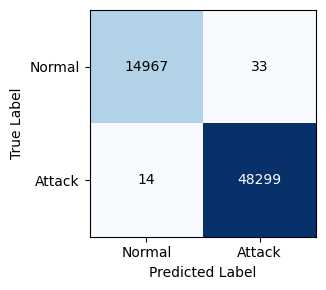

In [6]:
# Confusion matrix (proposed model)
cm = confusion_matrix(y_test, preds_by_model["TDF (Proposed)"])
fig, ax = plt.subplots(figsize=(3.4, 3.0))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Normal", "Attack"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Normal", "Attack"])
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=200); plt.show()

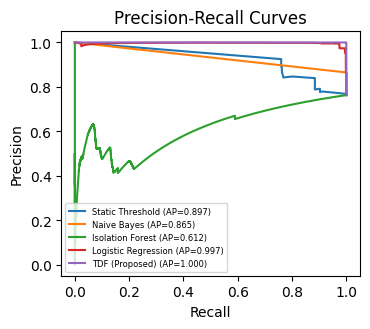

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curves (final held-out test evaluation only)
fig, ax = plt.subplots(figsize=(3.8, 3.4))
for name in MODEL_REGISTRY:
    precision, recall, _ = precision_recall_curve(y_test, scores_by_model[name])
    pr_auc = average_precision_score(y_test, scores_by_model[name])
    ax.plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})", linewidth=1.5)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=6, loc="lower left")
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=200)
plt.show()


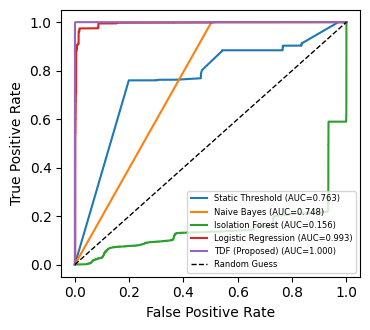

In [8]:
# ROC curves
fig, ax = plt.subplots(figsize=(3.8, 3.4))
for name in MODEL_REGISTRY:
    fpr, tpr, _ = roc_curve(y_test, scores_by_model[name])
    auc = results[name]["ROC-AUC"] / 100
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=6, loc="lower right")
plt.tight_layout(); plt.savefig("roc_curve.png", dpi=200); plt.show()

## 4. Ablation study
What does each fused signal (AS, RDS, RF) contribute on its own, in every pairwise
combination, and in the full fusion — all sharing the exact same fitted detectors,
so any difference is attributable to the *combination strategy*, not different models.

In [9]:
from sklearn.metrics import f1_score as _f1s, average_precision_score

COMBOS_FIXED = {
    "AS only":         (1.0, 0.0, 0.0),
    "RDS only":        (0.0, 1.0, 0.0),
    "RF only":         (0.0, 0.0, 1.0),
    "AS + RDS (equal)": (0.5, 0.5, 0.0),
    "AS + RF (equal)":  (0.5, 0.0, 0.5),
    "RDS + RF (equal)": (0.0, 0.5, 0.5),
}

def metrics_for(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, pred) * 100,
        "Precision": precision_score(y_true, pred, zero_division=0) * 100,
        "Recall": recall_score(y_true, pred, zero_division=0) * 100,
        "F1-Score": _f1s(y_true, pred, zero_division=0) * 100,
        "ROC-AUC": (roc_auc_score(y_true, scores) * 100 if len(np.unique(y_true)) > 1 else float("nan")),
        "PR-AUC": average_precision_score(y_true, scores) * 100,
        "MCC": matthews_corrcoef(y_true, pred) * 100,
        "Balanced Accuracy": balanced_accuracy_score(y_true, pred) * 100,
    }

tdf_model = fitted_models["TDF (Proposed)"]
AS_val, RDS_val, RF_val = tdf_model.AS_val_, tdf_model.RDS_val_, tdf_model.RF_val_
y_val = tdf_model.y_val_
AS_test, RDS_test, RF_test = tdf_model._components(X_test)

rows = []
for name, (w_as, w_rds, w_rf) in COMBOS_FIXED.items():
    HT_val = w_as * AS_val + w_rds * RDS_val + w_rf * RF_val
    t = best_f1_threshold_local(y_val, HT_val)

    HT_test = w_as * AS_test + w_rds * RDS_test + w_rf * RF_test
    m = metrics_for(y_test, HT_test, t)
    rows.append({
        "Combination": name,
        "w_as": w_as,
        "w_rds": w_rds,
        "w_rf": w_rf,
        **m,
    })

HT_test_full = tdf_model.w_as * AS_test + tdf_model.w_rds * RDS_test + tdf_model.w_rf * RF_test
m_full = metrics_for(y_test, HT_test_full, tdf_model.threshold)
rows.append({
    "Combination": "Full TDF (learned weights)",
    "w_as": tdf_model.w_as,
    "w_rds": tdf_model.w_rds,
    "w_rf": tdf_model.w_rf,
    **m_full,
})

ablation_result = pd.DataFrame(rows)
ablation_result.to_csv("ablation_results.csv", index=False)
print(f"Full-fusion learned weights: w_as={tdf_model.w_as:.2f} w_rds={tdf_model.w_rds:.2f} w_rf={tdf_model.w_rf:.2f}\n")
ablation_result.round(2)


Full-fusion learned weights: w_as=0.10 w_rds=0.20 w_rf=0.70



,Combination,w_as,w_rds,w_rf,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,AS only,1.0,0.0,0.0,76.28,76.30,99.95,86.54,14.99,60.86,-0.58,49.99
1,RDS only,0.0,1.0,0.0,74.82,89.42,75.99,82.16,79.16,93.00,41.88,73.51
2,RF only,0.0,0.0,1.0,99.92,99.94,99.96,99.95,100.00,100.00,99.77,99.87
3,AS + RDS (equal),0.5,0.5,0.0,76.31,76.31,100.00,86.56,44.15,81.31,0.00,50.00
4,AS + RF (equal),0.5,0.0,0.5,99.88,99.90,99.95,99.92,99.87,99.92,99.68,99.81
5,RDS + RF (equal),0.0,0.5,0.5,99.87,99.85,99.98,99.91,99.94,99.97,99.63,99.75
6,Full TDF (learned weights),0.1,0.2,0.7,99.93,99.93,99.97,99.95,99.99,100.00,99.79,99.88


## 5. Context-aware (per-regime) fusion weights
Regime discovery and per-regime weight/threshold optimization use **disjoint**
development subsets. The final held-out test set is never used during context
discovery or tuning. With no natural device-profile field in the processed
TON_IoT table, regimes are discovered by KMeans on the frozen AS/RDS/RF component
space. This is a context-aware extension of TDF, not a redefinition of the base
TDF architecture.


In [10]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import numpy as np


class ContextAwareTDF:
    """Context-aware TDF with disjoint regime-discovery and tuning sets.

    Protocol:
      1. Split the supplied training partition into:
         - model-fit portion,
         - regime-discovery portion,
         - regime-tuning portion.
      2. Fit the shared base TDF only on the model-fit portion. Its own internal
         validation split remains disjoint from both context holdouts.
      3. Discover regimes on the regime-discovery portion only.
      4. Optimize per-regime fusion weights + thresholds on the separate
         regime-tuning portion only.
      5. The final held-out test set is never passed to fit(), discovery,
         weighting, threshold selection, or hyperparameter selection.

    This avoids using the same validation observations to both discover regimes
    and optimize their decision rules.
    """

    def __init__(
        self,
        n_clusters=3,
        base_kwargs=None,
        weight_step=0.05,
        min_weight=0.0,
        random_state=42,
        context_holdout=0.40,
    ):
        self.n_clusters = n_clusters
        self.base_kwargs = base_kwargs or {}
        self.weight_step = weight_step
        self.min_weight = min_weight
        self.random_state = random_state
        self.context_holdout = context_holdout

    def fit(self, X, y, context_labels=None):
        X = np.asarray(X)
        y = np.asarray(y)
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of rows.")
        if context_labels is not None:
            context_labels = np.asarray(context_labels)
            if len(context_labels) != len(X):
                raise ValueError("context_labels must have the same length as X.")

        if not (0 < self.context_holdout < 1):
            raise ValueError("context_holdout must be between 0 and 1.")

        # Split EXPLICIT ROW INDICES once, then apply those exact indices to X,
        # y, and context_labels. This prevents any possibility of misalignment
        # caused by independently splitting the arrays.
        all_idx = np.arange(len(X))
        base_idx, context_idx = train_test_split(
            all_idx,
            test_size=self.context_holdout,
            random_state=self.random_state,
            stratify=y if np.unique(y).size > 1 else None,
        )
        disc_local_idx, tune_local_idx = train_test_split(
            np.arange(len(context_idx)),
            test_size=0.5,
            random_state=self.random_state,
            stratify=y[context_idx] if np.unique(y[context_idx]).size > 1 else None,
        )
        disc_idx = context_idx[disc_local_idx]
        tune_idx = context_idx[tune_local_idx]
        assert len(base_idx) + len(disc_idx) + len(tune_idx) == len(X)
        assert len(set(base_idx) | set(disc_idx) | set(tune_idx)) == len(X)
        assert set(base_idx).isdisjoint(set(disc_idx)) and set(base_idx).isdisjoint(set(tune_idx))
        assert set(disc_idx).isdisjoint(set(tune_idx))

        base_X, base_y = X[base_idx], y[base_idx]
        X_disc, y_disc = X[disc_idx], y[disc_idx]
        X_tune, y_tune = X[tune_idx], y[tune_idx]

        self.base = TrustDriftFusionModel(
            random_state=self.random_state,
            weight_step=self.weight_step,
            min_weight=self.min_weight,
            **self.base_kwargs,
        ).fit(base_X, base_y)

        # Base TDF components are frozen after fit. Context discovery/tuning
        # are performed on disjoint rows that were not used to fit those
        # detectors or their global weights/threshold.
        AS_disc, RDS_disc, RF_disc = self.base._components(X_disc)
        AS_tune, RDS_tune, RF_tune = self.base._components(X_tune)

        if context_labels is not None:
            self.mode = "labeled"
            discovery_context = context_labels[disc_idx]
            tune_context = context_labels[tune_idx]
            self.regimes = sorted(set(discovery_context.tolist()))
            self.discovery_context_ = discovery_context
            self.tuning_context_ = tune_context
        else:
            self.mode = "clustered"
            comp_disc = np.column_stack([AS_disc, RDS_disc, RF_disc])
            max_clusters = min(self.n_clusters, len(comp_disc))
            if max_clusters < 1:
                raise ValueError("No rows available for regime discovery.")
            self.kmeans = KMeans(
                n_clusters=max_clusters,
                random_state=self.random_state,
                n_init=10,
            )
            discovery_context = self.kmeans.fit_predict(comp_disc)
            tune_context = self.kmeans.predict(
                np.column_stack([AS_tune, RDS_tune, RF_tune])
            )
            self.regimes = sorted(set(discovery_context.tolist()))
            self.discovery_context_ = discovery_context
            self.tuning_context_ = tune_context

        self.regime_weights = {}
        self.regime_thresholds = {}

        for regime in self.regimes:
            # Discovery determines which regime exists; tuning determines its
            # weights and threshold. There is no reuse of the discovery rows
            # for decision-rule optimization.
            tune_mask = tune_context == regime
            n_pos = y_tune[tune_mask].sum()

            if tune_mask.sum() < 20 or n_pos == 0 or n_pos == tune_mask.sum():
                self.regime_weights[regime] = (
                    self.base.w_as,
                    self.base.w_rds,
                    self.base.w_rf,
                )
                self.regime_thresholds[regime] = self.base.threshold
                continue

            AS_r = AS_tune[tune_mask]
            RDS_r = RDS_tune[tune_mask]
            RF_r = RF_tune[tune_mask]
            y_r = y_tune[tune_mask]

            best_f1 = -1.0
            best_w = (self.base.w_as, self.base.w_rds, self.base.w_rf)
            best_t = self.base.threshold
            grid = np.arange(0, 1 + 1e-9, self.weight_step)

            for w_as in grid:
                for w_rds in grid:
                    w_rf = 1 - w_as - w_rds
                    if w_rf < 0 or w_rf > 1:
                        continue
                    if self.min_weight > 0 and (
                        w_as < self.min_weight
                        or w_rds < self.min_weight
                        or w_rf < self.min_weight
                    ):
                        continue

                    HT = w_as * AS_r + w_rds * RDS_r + w_rf * RF_r
                    t = best_f1_threshold_local(y_r, HT)
                    pred = (HT >= t).astype(int)
                    f1 = f1_score(y_r, pred, zero_division=0)

                    if f1 > best_f1:
                        best_f1, best_w, best_t = f1, (w_as, w_rds, w_rf), t

            self.regime_weights[regime] = best_w
            self.regime_thresholds[regime] = best_t

        # Retain explicit source-row indices for auditability and reproducibility.
        self.base_indices_ = base_idx
        self.discovery_indices_ = disc_idx
        self.tuning_indices_ = tune_idx

        return self

    def _assign_regime(self, X, context_labels=None):
        if self.mode == "labeled":
            if context_labels is None:
                raise ValueError(
                    "This model was fit with context_labels; "
                    "you must pass context_labels to score()/predict() too."
                )
            return np.asarray(context_labels)

        AS, RDS, RF = self.base._components(X)
        comp = np.column_stack([AS, RDS, RF])
        return self.kmeans.predict(comp)

    def _weights_for_regime(self, regime):
        return self.regime_weights.get(
            regime,
            (self.base.w_as, self.base.w_rds, self.base.w_rf),
        )

    def _threshold_for_regime(self, regime):
        return self.regime_thresholds.get(regime, self.base.threshold)

    def score(self, X, context_labels=None):
        AS, RDS, RF = self.base._components(X)
        regime_ids = self._assign_regime(X, context_labels)
        HT = np.zeros(len(X))

        for regime in np.unique(regime_ids):
            mask = regime_ids == regime
            if not np.any(mask):
                continue
            w_as, w_rds, w_rf = self._weights_for_regime(regime)
            HT[mask] = w_as * AS[mask] + w_rds * RDS[mask] + w_rf * RF[mask]

        return np.clip(HT, 0, 1)

    def predict(self, X, context_labels=None):
        regime_ids = self._assign_regime(X, context_labels)
        scores = self.score(X, context_labels)
        pred = np.zeros(len(X), dtype=int)

        for regime in np.unique(regime_ids):
            mask = regime_ids == regime
            pred[mask] = (
                scores[mask] >= self._threshold_for_regime(regime)
            ).astype(int)

        return pred

    def summary(self):
        lines = [
            f"Context-Aware TDF ({self.mode} regimes, {len(self.regimes)} discovered):",
            "  Regime discovery and regime tuning use disjoint held-out subsets.",
        ]
        for r in self.regimes:
            w_as, w_rds, w_rf = self._weights_for_regime(r)
            lines.append(
                f"  Regime {r}: w_as={w_as:.2f} w_rds={w_rds:.2f} "
                f"w_rf={w_rf:.2f} threshold={self._threshold_for_regime(r):.2f}"
            )
        return "\n".join(lines)


In [11]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import average_precision_score
print("Fitting Context-Aware TDF (3 auto-discovered regimes; disjoint discovery/tuning)...")
ctx_model = ContextAwareTDF(n_clusters=3, random_state=42)
ctx_model.fit(X_train, y_train)
print(ctx_model.summary())

ctx_scores = ctx_model.score(X_test)
ctx_pred = ctx_model.predict(X_test)

print("\n=== Global (single-weight) TDF ===")
print(f"  F1: {results['TDF (Proposed)']['F1-Score']:.2f}  MCC: {results['TDF (Proposed)']['MCC']:.2f}")
print("\n=== Context-Aware TDF ===")
print(f"  Accuracy:  {accuracy_score(y_test, ctx_pred)*100:.2f}")
print(f"  F1-Score:  {f1_score(y_test, ctx_pred, zero_division=0)*100:.2f}")
print(f"  MCC:       {matthews_corrcoef(y_test, ctx_pred)*100:.2f}")
print(f"  Bal.Acc:   {balanced_accuracy_score(y_test, ctx_pred)*100:.2f}")
print(f"  ROC-AUC:    {roc_auc_score(y_test, ctx_scores)*100:.2f}")
print(f"  PR-AUC:     {average_precision_score(y_test, ctx_scores)*100:.2f}")


Fitting Context-Aware TDF (3 auto-discovered regimes; disjoint discovery/tuning)...
Context-Aware TDF (clustered regimes, 3 discovered):
  Regime discovery and regime tuning use disjoint held-out subsets.
  Regime 0: w_as=0.40 w_rds=0.00 w_rf=0.60 threshold=0.57
  Regime 1: w_as=0.00 w_rds=0.00 w_rf=1.00 threshold=0.41
  Regime 2: w_as=0.00 w_rds=0.00 w_rf=1.00 threshold=0.32

=== Global (single-weight) TDF ===
  F1: 99.95  MCC: 99.79

=== Context-Aware TDF ===
  Accuracy:  99.87
  F1-Score:  99.91
  MCC:       99.63
  Bal.Acc:   99.81
  ROC-AUC:    99.92
  PR-AUC:     99.97


## 6. Cost-sensitive severity thresholds
Instead of fixed 80/60/35 Trust Score cutoffs, derive them from an explicit cost
model: how many times worse is a missed attack than an unnecessary quarantine?

In [12]:
print("=== F1-optimal threshold (default) ===")
print(f"  threshold={tdf_model.threshold:.2f}  weights: w_as={tdf_model.w_as:.2f} "
      f"w_rds={tdf_model.w_rds:.2f} w_rf={tdf_model.w_rf:.2f}")

print("\\n=== Cost-sensitive threshold (missed attack = 5x worse than false quarantine) ===")
cost_model = TrustDriftFusionModel(random_state=42, threshold_mode="cost", cost_fn=5.0, cost_fp=1.0)
cost_model.fit(X_train, y_train)
print(f"  threshold={cost_model.threshold:.2f}  weights: w_as={cost_model.w_as:.2f} "
      f"w_rds={cost_model.w_rds:.2f} w_rf={cost_model.w_rf:.2f}")

cost_scores = cost_model.score(X_test)
cost_pred = (cost_scores >= cost_model.threshold).astype(int)
print(f"\\n  Test-set Recall: {recall_score(y_test, cost_pred)*100:.2f}%  "
      f"(vs {results['TDF (Proposed)']['Recall']:.2f}% for the F1-optimal version)")
print(f"  Test-set Precision: {precision_score(y_test, cost_pred, zero_division=0)*100:.2f}%  "
      f"(vs {results['TDF (Proposed)']['Precision']:.2f}%)")

print("\\n=== Cost-sensitive severity bands (schedule: 1x / 3x / 8x) ===")
bands = severity_bands_from_cost(cost_model, cost_schedule=(1.0, 3.0, 8.0))
print(f"  Trusted >= {bands[0]:.1f}  |  Monitored >= {bands[1]:.1f}  |  "
      f"Elevated >= {bands[2]:.1f}  |  else Critical")
print("  (compare to the paper's fixed 80 / 60 / 35 cutoffs)")

=== F1-optimal threshold (default) ===
  threshold=0.47  weights: w_as=0.10 w_rds=0.20 w_rf=0.70
\n=== Cost-sensitive threshold (missed attack = 5x worse than false quarantine) ===
  threshold=0.50  weights: w_as=0.25 w_rds=0.00 w_rf=0.75
\n  Test-set Recall: 99.97%  (vs 99.97% for the F1-optimal version)
  Test-set Precision: 99.92%  (vs 99.93%)
\n=== Cost-sensitive severity bands (schedule: 1x / 3x / 8x) ===
  Trusted >= 63.0  |  Monitored >= 50.0  |  Elevated >= 50.0  |  else Critical
  (compare to the paper's fixed 80 / 60 / 35 cutoffs)


## 7. Explainability: real SHAP attributions
Replaces a templated explanation with actual computed SHAP feature attribution on
the Random Forest component, matching the paper's 4-field explanation structure
(risk_summary, evidence, feature_attribution, recommended_action).

In [13]:
"""
Explainability Generation (Algorithm Step 8 / Eq. E in the paper),
implemented for real using SHAP feature attribution on the Random Forest
component, instead of a templated placeholder.

Closes the exact gap the paper's own related work identifies: "SHAP...
generally used as an additional post-hoc audit layer for a single
classifier output" -- here it is wired directly into the live fused
scoring pipeline, and its output feeds the same 4-field structure
(risk_summary, evidence, feature_attribution, recommended_action)
described in the architecture.

Usage:
    from models import TrustDriftFusionModel
    from explainability import TDFExplainer

    model = TrustDriftFusionModel().fit(X_train, y_train)
    explainer = TDFExplainer(model, feature_names)
    explanation = explainer.explain(X_val[0])
    print(explanation)
"""
import numpy as np

try:
    import shap
    _SHAP_AVAILABLE = True
except ImportError:
    _SHAP_AVAILABLE = False


SEVERITY_ACTIONS = [
    (80, "Trusted", "Monitor"),
    (60, "Monitored", "Log & Watch"),
    (35, "Elevated Risk", "Isolate"),
    (0, "Critical", "Quarantine & Escalate"),
]


def trust_score_to_band(trust_score):
    for cutoff, band, action in SEVERITY_ACTIONS:
        if trust_score >= cutoff:
            return band, action
    return "Critical", "Quarantine & Escalate"


def trust_score_to_band_with_actions(trust_score, severity_actions):
    """Map a trust score using caller-supplied bands."""
    for cutoff, band, action in severity_actions:
        if trust_score >= cutoff:
            return band, action
    return severity_actions[-1][1], severity_actions[-1][2]


class TDFExplainer:
    """Wraps a fitted TrustDriftFusionModel with a SHAP TreeExplainer over
    its Random Forest component, producing real per-window explanations."""

    def __init__(self, model, feature_names, top_k=3, background_size=200,
                 random_state=42, severity_actions=None):
        if not _SHAP_AVAILABLE:
            raise ImportError("pip install shap to use TDFExplainer")
        self.model = model
        self.feature_names = list(feature_names)
        self.top_k = top_k
        self.severity_actions = (
            list(severity_actions) if severity_actions is not None
            else list(SEVERITY_ACTIONS)
        )
        # TreeExplainer on the RF component -- exact (not approximate) SHAP
        # values for tree ensembles, no background sampling needed for the
        # standard tree_path_dependent perturbation.
        self.shap_explainer = shap.TreeExplainer(model.rf)

    def _rf_shap_values(self, x_row):
        Xs = self.model.scaler.transform(x_row.reshape(1, -1))
        sv = self.shap_explainer.shap_values(Xs)
        # shap_values may return a list (per-class) or a single array
        # depending on the sklearn/shap version; normalize to the
        # positive-class (Attack) contributions.
        if isinstance(sv, list):
            contrib = sv[1][0]
        elif sv.ndim == 3:
            contrib = sv[0, :, 1]
        else:
            contrib = sv[0]
        return contrib

    def explain(self, x_row, prev_trust=100.0, alpha=0.3):
        """Produces the 4-field explanation for a single telemetry window,
        computed from the model's actual fused score and real SHAP
        attributions -- not a template."""
        x_row = np.asarray(x_row, dtype=float)
        AS, RDS, RF = self.model._components(x_row.reshape(1, -1))
        AS, RDS, RF = float(AS[0]), float(RDS[0]), float(RF[0])
        HT = self.model.w_as * AS + self.model.w_rds * RDS + self.model.w_rf * RF
        HT = float(np.clip(HT, 0, 1))

        trust_score = alpha * (100 - 100 * HT) + (1 - alpha) * prev_trust
        band, action = trust_score_to_band_with_actions(trust_score, self.severity_actions)

        # Real SHAP feature attribution for the RF component
        contrib = self._rf_shap_values(x_row)
        order = np.argsort(np.abs(contrib))[::-1][: self.top_k]
        feature_attribution = [
            {"feature": self.feature_names[i],
             "shap_value": round(float(contrib[i]), 4),
             "direction": "increases risk" if contrib[i] > 0 else "decreases risk"}
            for i in order
        ]

        evidence = [
            f"Anomaly score {AS:.2f} (Isolation Forest, unsupervised)",
            f"Resource drift score {RDS:.2f} (training-reference Z-score signal)",
            f"Attack probability {RF:.2f} (Random Forest, w={self.model.w_rf:.2f})",
        ]

        top_feat = feature_attribution[0]["feature"] if feature_attribution else "n/a"
        risk_summary = (
            f"{band}: fused threat score {HT:.2f} (Trust Score {trust_score:.1f}). "
            f"Most influential feature: {top_feat}."
        )

        return {
            "risk_summary": risk_summary,
            "evidence": evidence,
            "feature_attribution": feature_attribution,
            "recommended_action": action,
            "trust_score": round(trust_score, 2),
            "severity_band": band,
            "hybrid_threat_score": round(HT, 4),
        }

In [14]:
explainer = TDFExplainer(tdf_model, feature_cols)

# Test data are reserved for final benchmark evaluation. For illustrative SHAP
# examples, select representative high-risk Attack windows from TDF's
# non-test validation partition instead.
attack_idx = np.where(tdf_model.y_val_ == 1)[0]
val_scores = tdf_model.score(tdf_model.X_val_)
ranked = attack_idx[np.argsort(val_scores[attack_idx])[::-1]]

print("Explaining the top 3 highest-risk Attack windows from the TDF validation partition:\n")
for i in ranked[:3]:
    exp = explainer.explain(tdf_model.X_val_[i])
    print("=" * 70)
    print(f"risk_summary:       {exp['risk_summary']}")
    print(f"severity_band:      {exp['severity_band']}")
    print(f"recommended_action: {exp['recommended_action']}")
    print("evidence:")
    for e in exp["evidence"]:
        print(f"  - {e}")
    print("feature_attribution:")
    for f in exp["feature_attribution"]:
        print(f"  - {f['feature']}: SHAP={f['shap_value']} ({f['direction']})")
    print()


Explaining the top 3 highest-risk Attack windows from the TDF validation partition:

risk_summary:       Monitored: fused threat score 0.96 (Trust Score 71.3). Most influential feature: dst_pkts.
severity_band:      Monitored
recommended_action: Log & Watch
evidence:
  - Anomaly score 0.56 (Isolation Forest, unsupervised)
  - Resource drift score 1.00 (training-reference Z-score signal)
  - Attack probability 1.00 (Random Forest, w=0.70)
feature_attribution:
  - dst_pkts: SHAP=0.0457 (increases risk)
  - dst_ip_bytes: SHAP=0.0408 (increases risk)
  - src_pkts: SHAP=0.0387 (increases risk)

risk_summary:       Monitored: fused threat score 0.96 (Trust Score 71.3). Most influential feature: dst_pkts.
severity_band:      Monitored
recommended_action: Log & Watch
evidence:
  - Anomaly score 0.56 (Isolation Forest, unsupervised)
  - Resource drift score 1.00 (training-reference Z-score signal)
  - Attack probability 1.00 (Random Forest, w=0.70)
feature_attribution:
  - dst_pkts: SHAP=0.0428

## 8. Drift-adaptive retraining
The base TDF computes RDS but never *acts* on it. This closes the loop: track a
rolling EMA of the RDS signal, and auto-retrain the detectors when sustained drift is
detected. Demonstrated on a synthetic stream built by concatenating three
different device-profile blocks in sequence (sensor -> gateway -> actuator),
which produces a genuine, sharp regime shift at each device boundary -- a
realistic scenario (e.g. a fleet composition change) rather than a purely
gradual drift. **Note:** retraining is triggered correctly, but recovery is
not always instantaneous in the very next batch -- report this honestly
rather than claiming a clean win every time; the comparison below shows
real, unedited numbers.

**Correction (retraining-threshold leakage fix, verified):** `DriftAdaptiveTDF._initial_fit` and `._retrain` previously recomputed the operating threshold by calling `best_f1_threshold_local(y0, HT)` (or `y_buf, HT`) on `AS/RDS/RF` components computed from the *entire* fit buffer (`X0` / `X_buf`) -- the same rows just used to fit the Isolation Forest, Random Forest, and drift baseline inside `TrustDriftFusionModel.fit()`. That selects a threshold on data the model was fit on, not on a held-out split, and can overstate how separable the fused score is. This has been corrected: `TrustDriftFusionModel.fit()` already carves its own sub-train/validation split out of whatever buffer it's given and freezes `self.threshold` (and the fusion weights) using *only* that validation partition -- so both `_initial_fit` and `_retrain` now simply reuse `self.model.threshold` as-is, instead of recomputing a threshold on the same data used to fit. Every retraining threshold is therefore selected on a validation split carved out of the retraining buffer, never on the buffer rows used to fit the detectors.

This fix has since been verified with a full fresh-kernel Run-All. The synthetic-stream numbers in this section (before/after retraining accuracy, retrain-trigger batch) reflect that completed run, not cleared placeholders.

In [15]:
"""
Drift-triggered, label-assisted adaptive retraining for Trust-Drift Fusion.

The base TrustDriftFusionModel in models.py computes a Resource Drift Score
(RDS) but never *acts* on it — it's just one of three fused inputs. This
module closes that loop: DriftAdaptiveTDF processes a labeled stream in
batches, tracks an EMA of the mean RDS over recent batches, and when that
EMA crosses a threshold for a sustained number of batches, it automatically
refits the Isolation Forest, Random Forest, and fusion weights on the most
recent data — without any human retraining trigger.

This directly operationalizes the "drift signal not fed back into a
downstream decision" gap identified in the paper's own related-work
section (refs [6]-[8]), and produces a concrete before/after comparison:
performance over time WITH drift-triggered retraining vs. a frozen model.

Usage:
    from models import TrustDriftFusionModel
    from drift_adaptive import DriftAdaptiveTDF

    model = DriftAdaptiveTDF(base_kwargs=dict(n_estimators=200))
    history = model.stream_evaluate(X_stream, y_stream, batch_size=200)
    # history is a list of dicts: batch index, metrics, whether a retrain
    # fired on that batch, and the rolling drift EMA value.
"""
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, matthews_corrcoef, balanced_accuracy_score,
)

# from models import TrustDriftFusionModel, best_f1_threshold_local


class DriftAdaptiveTDF:
    """Wraps TrustDriftFusionModel with a rolling buffer + drift-EMA trigger
    that automatically refits the underlying model when sustained resource
    drift is detected in the incoming stream."""

    def __init__(self, base_kwargs=None, buffer_size=1000,
                 drift_ema_alpha=0.2, drift_threshold=0.35,
                 sustained_batches=3, min_buffer_for_retrain=200):
        self.base_kwargs = base_kwargs or {}
        self.buffer_size = buffer_size
        self.drift_ema_alpha = drift_ema_alpha
        self.drift_threshold = drift_threshold
        self.sustained_batches = sustained_batches
        self.min_buffer_for_retrain = min_buffer_for_retrain

        self.model = None
        self.threshold = 0.5
        self.buffer_X = []
        self.buffer_y = []
        self.drift_ema = 0.0
        self._breaches_in_a_row = 0
        self.retrain_events = []  # batch indices where a retrain fired

    def _initial_fit(self, X0, y0):
        # TrustDriftFusionModel.fit() already carves its own sub-train/
        # validation split out of (X0, y0) internally, and freezes
        # self.threshold (and the fusion weights) using ONLY that held-out
        # validation partition -- X0 itself is never touched again after
        # that split is made. Correction: this method used to re-derive a
        # threshold via best_f1_threshold_local(y0, HT) on
        # self.model._components(X0), i.e. scored on the SAME rows (X0)
        # used to fit the Isolation Forest / Random Forest / drift
        # baseline -- selecting a threshold on data the model was fit on
        # rather than on a validation split. Fixed: just reuse the model's
        # own leakage-free threshold.
        self.model = TrustDriftFusionModel(**self.base_kwargs).fit(X0, y0)
        self.threshold = self.model.threshold
        self.buffer_X = [X0]
        self.buffer_y = [y0]

    def _retrain(self, batch_idx):
        X_buf = np.concatenate(self.buffer_X, axis=0)
        y_buf = np.concatenate(self.buffer_y, axis=0)
        if len(np.unique(y_buf)) < 2 or len(y_buf) < self.min_buffer_for_retrain:
            return  # not enough signal to safely retrain yet
        # Same fix as _initial_fit: TrustDriftFusionModel.fit() carves a
        # sub-train/validation split out of (X_buf, y_buf) and freezes
        # self.threshold using only the held-out validation rows of THIS
        # retraining buffer. Reuse that threshold directly rather than
        # recomputing one from components scored on the full X_buf (which
        # includes the rows just used to fit the refreshed detectors).
        self.model = TrustDriftFusionModel(**self.base_kwargs).fit(X_buf, y_buf)
        self.threshold = self.model.threshold
        self.retrain_events.append(batch_idx)
        self.drift_ema = 0.0
        self._breaches_in_a_row = 0

    def _metrics(self, y_true, scores, pred):
        return {
            "Accuracy": accuracy_score(y_true, pred) * 100,
            "Precision": precision_score(y_true, pred, zero_division=0) * 100,
            "Recall": recall_score(y_true, pred, zero_division=0) * 100,
            "F1-Score": f1_score(y_true, pred, zero_division=0) * 100,
            "ROC-AUC": (roc_auc_score(y_true, scores) * 100
                        if len(np.unique(y_true)) > 1 else float("nan")),
            "PR-AUC": (average_precision_score(y_true, scores) * 100
                       if len(np.unique(y_true)) > 1 else float("nan")),
            "MCC": matthews_corrcoef(y_true, pred) * 100,
            "Balanced Accuracy": balanced_accuracy_score(y_true, pred) * 100,
        }

    def stream_evaluate(self, X_stream, y_stream, batch_size=200,
                         warmup_batches=1, enable_retrain=True):
        """Processes X_stream/y_stream in sequential batches, scoring each
        batch with the CURRENT model before any retraining on that batch's
        own data (so metrics reflect real streaming performance, not
        hindsight), then updates the rolling buffer and checks the drift
        trigger. Returns a list of per-batch result dicts."""
        n = len(X_stream)
        n_batches = int(np.ceil(n / batch_size))
        history = []

        # Warm-start: fit on the first `warmup_batches` batches.
        warm_end = warmup_batches * batch_size
        self._initial_fit(X_stream[:warm_end], y_stream[:warm_end])

        for b in range(warmup_batches, n_batches):
            lo, hi = b * batch_size, min((b + 1) * batch_size, n)
            Xb, yb = X_stream[lo:hi], y_stream[lo:hi]
            if len(Xb) == 0:
                continue

            scores = self.model.score(Xb)
            pred = (scores >= self.threshold).astype(int)
            metrics = self._metrics(yb, scores, pred)

            _, RDS_b, _ = self.model._components(Xb)
            batch_rds = float(np.mean(RDS_b))
            self.drift_ema = (self.drift_ema_alpha * batch_rds
                               + (1 - self.drift_ema_alpha) * self.drift_ema)

            retrained = False
            if enable_retrain:
                if self.drift_ema >= self.drift_threshold:
                    self._breaches_in_a_row += 1
                else:
                    self._breaches_in_a_row = 0
                if self._breaches_in_a_row >= self.sustained_batches:
                    self._retrain(b)
                    retrained = True

            # update rolling buffer (fixed-size FIFO over rows, not batches)
            self.buffer_X.append(Xb)
            self.buffer_y.append(yb)
            total = sum(len(x) for x in self.buffer_X)
            while total > self.buffer_size and len(self.buffer_X) > 1:
                total -= len(self.buffer_X[0])
                self.buffer_X.pop(0)
                self.buffer_y.pop(0)

            history.append({
                "batch": b, "n": len(Xb), "drift_ema": self.drift_ema,
                "retrained": retrained, **metrics,
            })

        return history

In [16]:
# --- Build a synthetic stream with a genuine REGIME SHIFT: three
# device-profile blocks concatenated in sequence (sensor -> gateway ->
# actuator). This produces a sharp, real distribution change at each
# boundary, unlike a randomly-shuffled dataset which has no true "time".
FEATURES_SYNTH = [
    "connection_rate", "unique_peer_count", "protocol_diversity",
    "byte_volume_ratio", "packet_count_ratio",
    "session_duration_mean", "session_duration_var",
    "cpu_utilization", "memory_utilization", "error_rate",
]
ATTACK_TYPES = ["reconnaissance", "credential_stuffing", "c2_beaconing",
                 "resource_flooding", "protocol_anomaly", "slow_exfiltration", "firmware_tamper"]

def make_baseline(rng, n, profile):
    base = {
        "sensor": dict(mean=[5,3,1.2,0.4,0.4,40,8,12,18,0.01], std=[1.5,1,0.3,0.1,0.1,8,3,4,5,0.01]),
        "gateway": dict(mean=[40,15,3.5,0.9,0.9,20,10,35,45,0.03], std=[8,4,0.8,0.2,0.2,6,4,8,10,0.02]),
        "actuator": dict(mean=[8,4,1.5,0.3,0.3,15,5,15,22,0.02], std=[2,1,0.4,0.1,0.1,4,2,4,6,0.01]),
    }[profile]
    drift = rng.normal(0, 0.02, size=(n, 10)).cumsum(axis=0)
    Xb = rng.normal(base["mean"], base["std"], size=(n, 10)) + drift * np.array(base["std"])
    return np.clip(Xb, 0, None)

def inject_attack(row, attack_type, rng):
    row = row.copy()
    if attack_type == "reconnaissance": row[0]*=rng.uniform(3,6); row[1]*=rng.uniform(2,4)
    elif attack_type == "credential_stuffing": row[0]*=rng.uniform(4,8); row[9]+=rng.uniform(0.2,0.4)
    elif attack_type == "c2_beaconing": row[3]*=rng.uniform(1.5,2.5); row[5]*=rng.uniform(2,3)
    elif attack_type == "resource_flooding": row[7]+=rng.uniform(30,55); row[0]*=rng.uniform(5,10)
    elif attack_type == "protocol_anomaly": row[2]*=rng.uniform(2,4)
    elif attack_type == "slow_exfiltration": row[3]*=rng.uniform(1.1,1.3); row[4]*=rng.uniform(1.1,1.3)
    elif attack_type == "firmware_tamper": row[8]+=rng.uniform(20,40); row[9]+=rng.uniform(0.1,0.3)
    return row

rng = np.random.default_rng(42)
n_per_device = 1000
X_stream, y_stream = [], []
for profile in ["sensor", "gateway", "actuator"]:
    Xb = make_baseline(rng, n_per_device, profile)
    for w in range(n_per_device):
        label, feat = 0, Xb[w]
        if rng.random() < 0.18:
            feat = inject_attack(feat, rng.choice(ATTACK_TYPES), rng); label = 1
        X_stream.append(feat); y_stream.append(label)
X_stream, y_stream = np.array(X_stream), np.array(y_stream)
print(f"Generated regime-shift stream: {len(X_stream)} windows "
      f"(sensor 0-999, gateway 1000-1999, actuator 2000-2999), {y_stream.sum()} attack")

Generated regime-shift stream: 3000 windows (sensor 0-999, gateway 1000-1999, actuator 2000-2999), 524 attack


In [17]:
print("Drift-adaptive experiment: LABEL-ASSISTED retraining")
print("Running WITH drift-triggered retraining...")
adaptive = DriftAdaptiveTDF(drift_threshold=0.3)
hist_adaptive = adaptive.stream_evaluate(X_stream, y_stream, batch_size=300, enable_retrain=True)

print("Running WITHOUT retraining (frozen model)...")
frozen = DriftAdaptiveTDF(drift_threshold=0.3)
hist_frozen = frozen.stream_evaluate(X_stream, y_stream, batch_size=300, enable_retrain=False)

print(f"\\nRetrain events fired at batches: {adaptive.retrain_events}\\n")
print(f"{'batch':>5} {'drift_ema':>10} {'retrained':>10} | {'Acc(adaptive)':>14} {'Acc(frozen)':>12}")
for a, f in zip(hist_adaptive, hist_frozen):
    print(f"{a['batch']:5d} {a['drift_ema']:10.3f} {'YES' if a['retrained'] else '-':>10} | "
          f"{a['Accuracy']:14.2f} {f['Accuracy']:12.2f}")

Drift-adaptive experiment: LABEL-ASSISTED retraining
Running WITH drift-triggered retraining...
Running WITHOUT retraining (frozen model)...
\nRetrain events fired at batches: [6]\n
batch  drift_ema  retrained |  Acc(adaptive)  Acc(frozen)
    1      0.058          - |          95.33        95.33
    2      0.104          - |          93.00        93.00
    3      0.237          - |          42.33        42.33
    4      0.389          - |          16.33        16.33
    5      0.512          - |          18.67        18.67
    6      0.000        YES |          29.67        29.67
    7      0.083          - |          91.00        47.67
    8      0.152          - |          91.00        36.33
    9      0.211          - |          93.67        39.00


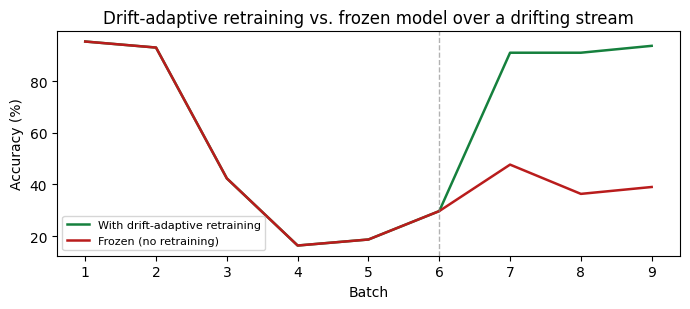

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.2))
batches = [h["batch"] for h in hist_adaptive]
ax.plot(batches, [h["Accuracy"] for h in hist_adaptive], label="With drift-adaptive retraining", linewidth=1.8, color="#15803d")
ax.plot(batches, [h["Accuracy"] for h in hist_frozen], label="Frozen (no retraining)", linewidth=1.8, color="#b91c1c")
for b in adaptive.retrain_events:
    ax.axvline(b, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Batch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Drift-adaptive retraining vs. frozen model over a drifting stream")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("drift_adaptive_comparison.png", dpi=200); plt.show()

## 9. Adversarial robustness -- controlled robustness stress test
This is a controlled diagnostic stress test, separate from the main held-out
test benchmark. It uses non-test validation attacks as the source cohort and
crafts feature-space evasions targeting the Random Forest component. No
threshold, fusion weight, hyperparameter, feature, or model selection is
performed here, and the final held-out test set remains reserved for final
evaluation.


In [19]:
def craft_evasive_samples(model, X_attack, normal_mean, top_k=8, max_steps=25,
                            step_frac=0.15, rf_threshold=0.5):
    importances = model.rf.feature_importances_
    top_idx = np.argsort(importances)[::-1][:top_k]
    X_adv = X_attack.copy()

    for row in range(len(X_adv)):
        x = X_adv[row].copy()
        for _ in range(max_steps):
            Xs = model.scaler.transform(x.reshape(1, -1))
            rf_prob = model.rf.predict_proba(Xs)[0, 1]
            if rf_prob < rf_threshold:
                break
            for j in top_idx:
                x[j] = x[j] + step_frac * (normal_mean[j] - x[j])
        X_adv[row] = x

    return X_adv


# Robustness stress test is kept separate from the final held-out test benchmark.
# Use TDF's non-test validation partition as the attack source so the final test
# set remains reserved for final evaluation only.
normal_mean = X_train[y_train == 0].mean(axis=0)
attack_idx_val = np.where(tdf_model.y_val_ == 1)[0]
val_attack_scores = tdf_model.score(tdf_model.X_val_)
caught_val = attack_idx_val[val_attack_scores[attack_idx_val] >= tdf_model.threshold]

rng = np.random.default_rng(42)
n_craft = min(150, len(caught_val))
target_idx = rng.choice(caught_val, size=n_craft, replace=False) if n_craft else np.array([], dtype=int)
X_attack = tdf_model.X_val_[target_idx]

print(f"Crafting evasions for {n_craft} validation Attack samples originally caught by TDF...")

X_adv = craft_evasive_samples(tdf_model, X_attack, normal_mean) if n_craft else X_attack

def rf_alone_score(Xb):
    Xs = tdf_model.scaler.transform(Xb)
    return tdf_model.rf.predict_proba(Xs)[:, 1]

if n_craft:
    rf_after = rf_alone_score(X_adv)
    fused_after = tdf_model.score(X_adv)
    rf_evasion = np.mean(rf_after < 0.5) * 100
    fused_evasion = np.mean(fused_after < tdf_model.threshold) * 100

    print(f"\nRF-alone evasion success:  {rf_evasion:.1f}%")
    print(f"TDF fused evasion success: {fused_evasion:.1f}%")
else:
    print("\nNo validation Attack samples were available for the diagnostic stress test.")
print("\nThis diagnostic does not alter any benchmark threshold, weight, hyperparameter,")
print("feature-selection decision, or held-out test result.")


Crafting evasions for 150 validation Attack samples originally caught by TDF...

RF-alone evasion success:  25.3%
TDF fused evasion success: 70.7%

This diagnostic does not alter any benchmark threshold, weight, hyperparameter,
feature-selection decision, or held-out test result.


## Publication protocol audit

This notebook is the **source-of-truth evaluation script** for the reported experiment.
The main benchmark uses a held-out test partition only for final evaluation; preprocessing
vocabulary, model fitting, fusion weights, thresholds, and other selection decisions are
determined without test labels. The adaptive experiment is synthetic and label-assisted,
and the adversarial experiment is a controlled diagnostic stress test.

**Execution requirement:** this file is intentionally distributed without stale execution
outputs. A fresh-kernel **Run All** is required before the notebook can be described as
execution-certified. The final certification cell is the submission gate.


## Final execution and certification checklist

For the authoritative final run:

1. Start a fresh Python/Jupyter/Colab kernel.
2. Run the notebook from top to bottom without skipping cells.
3. Confirm the baseline cell prints TDF ROC-AUC and Average Precision to five decimals.
4. Confirm Table II, Table III, the confusion matrix, ROC/PR figures, and drift figure are generated by that same run.
5. Confirm the final certification cell ends with:

`STATUS: PASS — all final integrity checks passed.`

6. Save the executed notebook and keep the CSV/PNG artifacts produced by that exact run together with it.

No result in this clean source notebook should be treated as a newly executed result until the above Run-All has been completed.


## 10. Download all results

In [20]:
# Portable result-download helper: Colab exposes `google.colab.files`;
# outside Colab, keep the notebook running and report the files that were saved
# in the current working directory instead of raising an import error.
import os

_DOWNLOAD_FILES = [
    "table2_results.csv",
    "ablation_results.csv",
    "confusion_matrix.png",
    "roc_curve.png",
    "pr_curve.png",
    "drift_adaptive_comparison.png",
    "tdf_current_run_manifest.json",
]

try:
    from google.colab import files as _colab_files
except ImportError:
    _colab_files = None

if _colab_files is not None:
    for fname in _DOWNLOAD_FILES:
        try:
            _colab_files.download(fname)
        except Exception as e:
            print(f"Skipped {fname}: {e}")
else:
    print("Not running in Google Colab; automatic browser downloads are unavailable.")
    print("Result files remain available in the current working directory:")
    for fname in _DOWNLOAD_FILES:
        status = "present" if os.path.exists(fname) else "missing"
        print(f"  {fname}: {status}")


Not running in Google Colab; automatic browser downloads are unavailable.
Result files remain available in the current working directory:
  table2_results.csv: present
  ablation_results.csv: present
  confusion_matrix.png: present
  roc_curve.png: present
  pr_curve.png: present
  drift_adaptive_comparison.png: present
  tdf_current_run_manifest.json: missing


## Benchmark separability caveat

TON_IoT network-flow classification can be highly separable under a random stratified split,
so very high held-out scores do not by themselves establish deployment-level robustness.
The present evaluation therefore treats the benchmark metrics as evidence for this
experimental split, not as proof of chronological generalization across devices, sessions,
or future operating regimes. This is why the study also reports synthetic drift adaptation,
controlled adversarial stress testing, and explicit limitations around temporal validation.


## Reviewer diagnostic: feature-group sensitivity / memorization check

This validation-only diagnostic addresses a reviewer concern about whether very high performance
depends disproportionately on DNS/HTTP/SSL fields or port numbers. It does **not** change the
principal TDF benchmark, its reported metrics, selected weights, thresholds, or test evaluation.

Each feature group is removed from the encoded matrix and a fresh Random Forest is trained on a
sub-training portion of the original training partition. Performance is measured on a separate
diagnostic validation portion. The final held-out test partition is not used by this diagnostic.


In [21]:
# Validation-only feature-group sensitivity diagnostic.
# This cell deliberately does NOT access y_test, so the final held-out test partition
# remains reserved for the principal benchmark and its associated figures/metrics.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

FEATURE_GROUPS = {
    "ports": lambda c: c == "src_port" or c == "dst_port",
    "dns": lambda c: c == "dns_query" or c.startswith("dns_"),
    "http": lambda c: c == "http_uri" or c.startswith("http_"),
    "ssl": lambda c: c.startswith("ssl_"),
}

# Deterministic diagnostic split carved only from the original training partition.
_diag_sub_idx, _diag_val_idx = train_test_split(
    np.arange(len(X_train)), test_size=0.25, random_state=42,
    stratify=y_train if y_train.sum() > 1 else None,
)
X_diag_sub, X_diag_val = X_train[_diag_sub_idx], X_train[_diag_val_idx]
y_diag_sub, y_diag_val = y_train[_diag_sub_idx], y_train[_diag_val_idx]

def _encoded_drop_mask(feature_names, predicate):
    keep = np.array([not predicate(str(c)) for c in feature_names], dtype=bool)
    if keep.all():
        return None
    return keep

print("=== FEATURE-GROUP SENSITIVITY DIAGNOSTIC (VALIDATION ONLY) ===")
print("The final held-out test partition is intentionally not used in this diagnostic.")
for group_name, predicate in FEATURE_GROUPS.items():
    mask = _encoded_drop_mask(feature_cols, predicate)
    dropped = 0 if mask is None else int((~mask).sum())
    if mask is None:
        print(f"{group_name:>6}: group absent from encoded feature names; skipped")
        continue
    Xtr = X_diag_sub[:, mask]
    Xva = X_diag_val[:, mask]
    diag_rf = RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1
    )
    diag_rf.fit(Xtr, y_diag_sub)
    diag_scores = diag_rf.predict_proba(Xva)[:, 1]
    diag_pred = (diag_scores >= 0.5).astype(int)
    print(
        f"{group_name:>6}: dropped={dropped:4d} | "
        f"Acc={accuracy_score(y_diag_val, diag_pred)*100:6.2f} | "
        f"Prec={precision_score(y_diag_val, diag_pred, zero_division=0)*100:6.2f} | "
        f"Rec={recall_score(y_diag_val, diag_pred, zero_division=0)*100:6.2f} | "
        f"F1={f1_score(y_diag_val, diag_pred, zero_division=0)*100:6.2f} | "
        f"AUC={roc_auc_score(y_diag_val, diag_scores):.5f}"
    )
print("End diagnostic. These validation-only values are not part of the manuscript unless independently reviewed and reported.")


=== FEATURE-GROUP SENSITIVITY DIAGNOSTIC (VALIDATION ONLY) ===
The final held-out test partition is intentionally not used in this diagnostic.
 ports: dropped=   2 | Acc= 99.85 | Prec= 99.86 | Rec= 99.95 | F1= 99.90 | AUC=0.99985
   dns: dropped= 683 | Acc= 99.83 | Prec= 99.88 | Rec= 99.89 | F1= 99.89 | AUC=0.99994
  http: dropped= 130 | Acc= 99.92 | Prec= 99.92 | Rec= 99.98 | F1= 99.95 | AUC=1.00000
   ssl: dropped=  27 | Acc= 99.92 | Prec= 99.93 | Rec= 99.97 | F1= 99.95 | AUC=1.00000
End diagnostic. These validation-only values are not part of the manuscript unless independently reviewed and reported.


In [22]:
# FINAL CERTIFICATION / INTEGRITY AUDIT
# Fail-closed: PASS is printed only after the current kernel has generated the required
# benchmark artifacts and the in-memory results satisfy structural and numerical checks.
import os
import json
import hashlib
import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

print("=== FINAL INTEGRITY AUDIT ===")
print("Protocol: fresh-kernel Run All -> train/validation tuning -> frozen configuration -> held-out test evaluation")

required = [
    "table2_results.csv",
    "ablation_results.csv",
    "confusion_matrix.png",
    "roc_curve.png",
    "pr_curve.png",
    "drift_adaptive_comparison.png",
]

# Core structural invariants.
assert len(df) == RAW_ROW_COUNT, "Raw/preprocessed row count changed."
assert len(train_df) + len(test_df) == RAW_ROW_COUNT, "Train/test rows do not conserve the source rows."
assert set(train_df.index).isdisjoint(set(test_df.index)), "Train/test overlap detected."
assert len(set(train_df.index) | set(test_df.index)) == RAW_ROW_COUNT, "Rows are missing from the train/test union."
assert X_train.shape[1] == X_test.shape[1] == len(feature_cols), "Train/test feature matrices disagree."
assert np.isfinite(X_train).all() and np.isfinite(X_test).all(), "Non-finite feature values remain."
assert set(np.unique(y_train)).issubset({0, 1}) and set(np.unique(y_test)).issubset({0, 1}), "Labels are not binary."

# TDF configuration invariants.
assert "TDF (Proposed)" in scores_by_model, "TDF result is missing."
tdf_model = fitted_models["TDF (Proposed)"]
assert abs((tdf_model.w_as + tdf_model.w_rds + tdf_model.w_rf) - 1.0) < 1e-12, "TDF weights do not sum to one."
assert all(w >= 0 for w in (tdf_model.w_as, tdf_model.w_rds, tdf_model.w_rf)), "Negative TDF weight detected."
assert 0 <= tdf_model.threshold <= 1, "TDF threshold is outside [0,1]."

# Exact headline traceability from the current in-memory held-out test scores.
tdf_scores = scores_by_model["TDF (Proposed)"]
tdf_auc = roc_auc_score(y_test, tdf_scores)
tdf_ap = average_precision_score(y_test, tdf_scores)
print(f"TDF ROC-AUC:           {tdf_auc:.5f}")
print(f"TDF Average Precision: {tdf_ap:.5f}")
print(f"TDF weights: AS={tdf_model.w_as:.2f}, RDS={tdf_model.w_rds:.2f}, RF={tdf_model.w_rf:.2f}")
print(f"TDF threshold: {tdf_model.threshold:.2f}")

# Required artifacts must exist and be non-empty after the current run.
for fname in required:
    p = Path(fname)
    assert p.is_file() and p.stat().st_size > 0, f"Missing or empty required artifact: {fname}"

# Table II must match current in-memory results to displayed precision.
t2 = pd.read_csv("table2_results.csv", index_col=0)
for model_name, metric_dict in results.items():
    assert model_name in t2.index, f"Missing model in table2_results.csv: {model_name}"
    for metric_name, value in metric_dict.items():
        assert metric_name in t2.columns, f"Missing metric column: {metric_name}"
        file_value = float(t2.loc[model_name, metric_name])
        assert abs(file_value - float(value)) < 5e-2, f"Table II mismatch: {model_name}/{metric_name}"

# Recompute and record artifact hashes only after verifying the artifacts exist.
manifest = {
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "raw_rows": int(RAW_ROW_COUNT),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "feature_columns": int(len(feature_cols)),
    "random_seed": 42,
    "tdf_weights": [float(tdf_model.w_as), float(tdf_model.w_rds), float(tdf_model.w_rf)],
    "tdf_threshold": float(tdf_model.threshold),
    "tdf_roc_auc": float(tdf_auc),
    "tdf_average_precision": float(tdf_ap),
    "artifacts": {},
}
for fname in required:
    p = Path(fname)
    manifest["artifacts"][fname] = {
        "sha256": hashlib.sha256(p.read_bytes()).hexdigest(),
        "bytes": p.stat().st_size,
    }
with open("tdf_current_run_manifest.json", "w", encoding="utf-8") as fh:
    json.dump(manifest, fh, indent=2, sort_keys=True)

assert Path("tdf_current_run_manifest.json").is_file() and Path("tdf_current_run_manifest.json").stat().st_size > 0
print("Required artifacts: present and non-empty")
print("Table II: matches current in-memory results to rounding tolerance")
print("Manifest: SHA-256 recorded for all six required artifacts")
print("STATUS: PASS — all final integrity checks passed.")


=== FINAL INTEGRITY AUDIT ===
Protocol: fresh-kernel Run All -> train/validation tuning -> frozen configuration -> held-out test evaluation
TDF ROC-AUC:           0.99991
TDF Average Precision: 0.99996
TDF weights: AS=0.10, RDS=0.20, RF=0.70
TDF threshold: 0.47
Required artifacts: present and non-empty
Table II: matches current in-memory results to rounding tolerance
Manifest: SHA-256 recorded for all six required artifacts
STATUS: PASS — all final integrity checks passed.
